In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

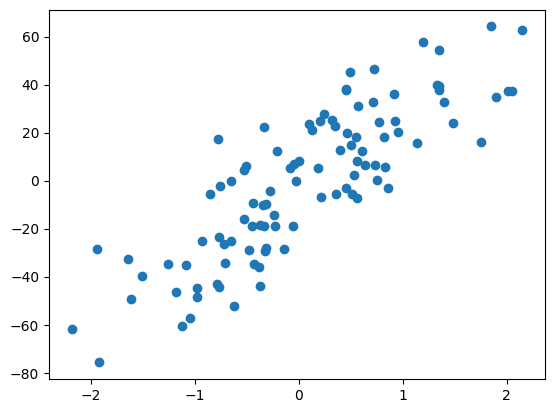

In [3]:
plt.scatter(X, y)
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [5]:
reg = LinearRegression()

reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
reg.coef_

array([28.12597332])

In [7]:
reg.intercept_

np.float64(-2.2710144261783825)

In [8]:
y_pred = reg.predict(X_test)

r2_score(y_test, y_pred)

0.6345158782661012

In [9]:
np.mean(cross_val_score(reg, X, y, scoring='r2', cv=10))

np.float64(0.6375011587464419)

In [10]:
class GDRegressor:

    def __init__(self, learning_rate,epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X, y):
        # calculate b using GD
        for i in range (self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m * X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m * X.ravel() - self.b)* X.ravel())
            
            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
            # print("Loss",loss_slope, "b", self.b)
        print(self.b, self.m)

    def predict(self, X):
        return self.m * X + self.b

In [11]:
gd = GDRegressor(0.001, 50)

In [12]:
gd.fit(X_train, y_train)

-2.3004574196824854 28.159367347119066


In [13]:
y_pred = gd.predict(X_test)
r2_score(y_test, y_pred)

0.6343842836315579